### Rain-on-snow project <br>
#### Definition of ROS zone and events accross NE US

In [1]:
import sys
# Path to ROS functions
sys.path.append('/users/m/m/mmorale3/netfiles/ciroh/mmorales/ROS_project/ros-workflow')

In [2]:
import functions.rain_on_snow_fncns as ros
from functions.rain_on_snow_fncns import nwm_proj
import geopandas
import matplotlib.pyplot as plt
import contextily as cx

In [3]:
from dask.distributed import Client
client = Client()
#clien = Client(n_workers=6, memory_limit='2GB') 
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 251.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44609,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44681,Total threads: 4
Dashboard: http://127.0.0.1:43251/status,Memory: 62.80 GiB
Nanny: tcp://127.0.0.1:39771,


1. Load NWM data

In [4]:
# Path to AWS NWM retrospective data
s3_path = 's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/ldasout.zarr'
timerange_test = slice('2019-01-01 00:00:00','2020-12-31 18:00:00')
variables = ["SNEQV", "QRAIN"]

In [5]:
%%time
ds_ne = ros.read_nwmData(awsPath = s3_path, variables = variables, timerange = timerange_test)

CPU times: user 1.32 s, sys: 164 ms, total: 1.48 s
Wall time: 3.45 s


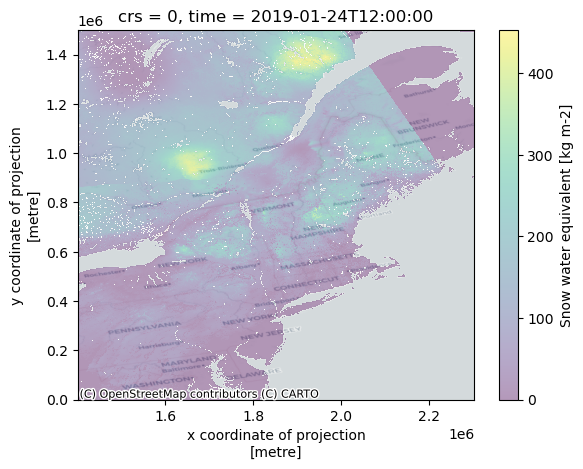

In [6]:
# Let's plot one time slice
timerange = slice('2019-01-24 12:00:00','2019-01-24 12:00:00')
#ds_sub2 = ds_sub.sel(time=timerange).QRAIN.persist() 
ds_sub2 = ds_ne.sel(time=timerange).SNEQV.persist() 

fig, axs = plt.subplots()
ds_sub2.plot(ax=axs, alpha=0.4)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

2. Get ROS daily mask with Musselman method

In [7]:
%%time
ros_daily_mask = ros.ros_musselman(ds_ne)

CPU times: user 171 ms, sys: 11.7 ms, total: 182 ms
Wall time: 188 ms


In [ ]:
#ros_daily_mask

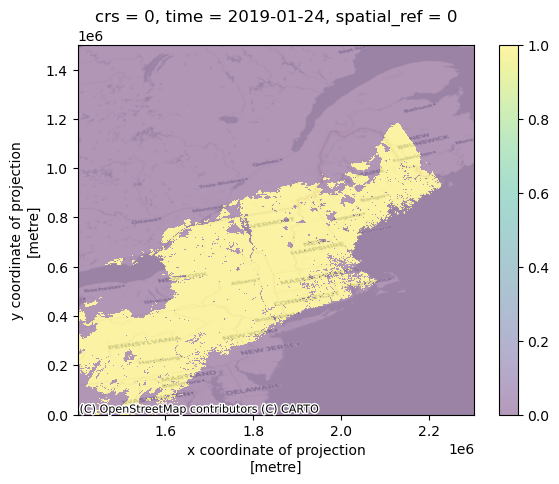

In [8]:
# Let'd pick a day for testing
test_ros = ros_daily_mask.isel(time=23)
fig, axs = plt.subplots()
test_ros.plot(ax=axs, alpha=0.4)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

3. Define ROS zone

In [9]:
%%time
# The threshold for the full retrospective period should be 43, but since we are testing with 2 years for now, it is set to 2.
ros_zone = ros.define_ros_zone(daily_ros_mask = ros_daily_mask, threshold = 2)

CPU times: user 9.89 s, sys: 989 ms, total: 10.9 s
Wall time: 50.9 s


4. Get ROS zone basins from GAGES II 

In [10]:
# Load GAGES II basins
shpPath = '~/netfiles/ciroh/mmorales/ROS_project/shapefiles/GAGES_II/boundaries_shapefiles_by_aggeco/boundaries-shapefiles-by-aggeco/'
fname = 'bas_ref_all.shp'
#fname = 'bas_nonref_NorthEast.shp'
shapefile = f'{shpPath}{fname}'

In [11]:
%%time
# The function will return a dataframe with the basins and % of grid cells within the ROS zone
ros_zone_bsns_df = ros.get_ros_basins(ros_zone = ros_zone,shpPath = shapefile)

CPU times: user 4.58 s, sys: 271 ms, total: 4.85 s
Wall time: 4.82 s


In [12]:
ros_zone_bsns_df

,GAGE_ID,Perc_ROS
0,01013500,80.0
1,01017550,24.0
2,01021470,100.0
3,01021480,100.0
4,01022260,98.0
...,...,...
299,01195100,0.0
300,01195200,0.0
301,01208990,0.0
302,01350000,57.0


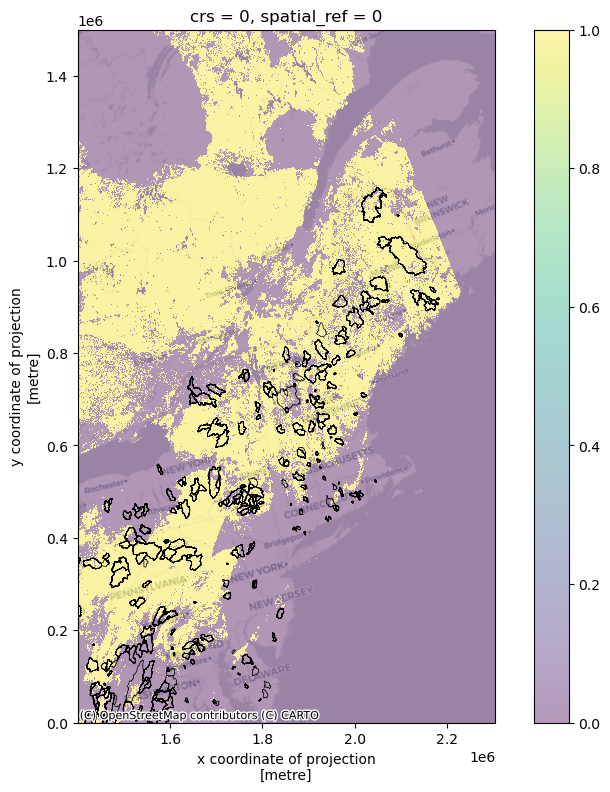

In [13]:
# Let's take a look at the basins and ros zone
shp = geopandas.read_file(shpPath, layer='bas_ref_all')
shp_prj = shp.to_crs(nwm_proj.crs)

fig, axs = plt.subplots(figsize=(10, 9))
ros_zone.plot(ax=axs, alpha=0.4)
shp_prj.plot(ax=axs,cmap=None,facecolor="none", edgecolor='k',linewidth=0.5)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

5. Extract ROS events for the provided basins

In [14]:
%%time
ros_events_df = ros.get_ros_events(ros_daily_mask = ros_daily_mask, shpPath = shapefile, t_chunks = 25)

CPU times: user 26.8 s, sys: 6.39 s, total: 33.2 s
Wall time: 1min 17s


In [15]:
ros_events_df

,GAGE_ID,Date,Perc_ROS
0,01013500,2019-01-01,0.0
1,01017550,2019-01-01,0.0
2,01021470,2019-01-01,0.0
3,01021480,2019-01-01,0.0
4,01022260,2019-01-01,0.0
...,...,...,...
222219,01195100,2020-12-31,0.0
222220,01195200,2020-12-31,0.0
222221,01208990,2020-12-31,0.0
222222,01350000,2020-12-31,0.0


In [16]:
# Let's export them into a csv file
ros_events_df.to_csv("ros_daily_gagesii_results.csv", index=False)

6. Get hydrologic properties for ROS events and for the provided basins